# TME 4 (6) Bagging and Boosting

Bagging is used to improve the accuracy of a classifier by training on differenet sets of the training data and then averaging across the predictions. 

Boosting is based on finding many small classifiers that solve small part of the problem, sequentially correcting errors of the other ones (weak classifier – only slightlly better than chance)

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np


In [17]:
import numpy as np
#from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm


def plot_data(data,labels=None):
    """
    Affiche des donnees 2D
    :param data: matrice des donnees 2d
    :param labels: vecteur des labels (discrets)
    :return:
    """
    if labels is not None:
        labels = labels.reshape(-1)
    cols,marks = ["red", "green", "blue", "orange", "black", "cyan"],[".","+","*","o","x","^"]
    if labels is None:
        plt.scatter(data[:,0],data[:,1],marker="x")
        return
    for i,l in enumerate(sorted(list(set(labels.flatten())))):
        plt.scatter(data[labels==l,0],data[labels==l,1],c=cols[i],marker=marks[i])

def plot_frontiere(data,f,step=20):
    """ Trace un graphe de la frontiere de decision de f
    :param data: donnees
    :param f: fonction de decision
    :param step: pas de la grille
    :return:
    """
    grid,x,y=make_grid(data=data,step=step)
    plt.contourf(x,y,f(grid).reshape(x.shape),colors=('gray','blue'),levels=[-1,0,1])

def make_grid(data=None,xmin=-5,xmax=5,ymin=-5,ymax=5,step=20):
    """ Cree une grille sous forme de matrice 2d de la liste des points
    :param data: pour calcluler les bornes du graphe
    :param xmin: si pas data, alors bornes du graphe
    :param xmax:
    :param ymin:
    :param ymax:
    :param step: pas de la grille
    :return: une matrice 2d contenant les points de la grille
    """
    if data is not None:
        xmax, xmin, ymax, ymin = np.max(data[:,0]),  np.min(data[:,0]), np.max(data[:,1]), np.min(data[:,1])
    x, y =np.meshgrid(np.arange(xmin,xmax,(xmax-xmin)*1./step), np.arange(ymin,ymax,(ymax-ymin)*1./step))
    grid=np.c_[x.ravel(),y.ravel()]
    return grid, x, y

def gen_arti(centerx=1,centery=1,sigma=0.1,nbex=1000,data_type=0,epsilon=0.02):
    """ Generateur de donnees,
        :param centerx: centre des gaussiennes
        :param centery:
        :param sigma: des gaussiennes
        :param nbex: nombre d'exemples
        :param data_type: 0: melange 2 gaussiennes, 1: melange 4 gaussiennes, 2:echequier
        :param epsilon: bruit dans les donnees
        :return: data matrice 2d des donnnes,y etiquette des donnnees
    """
    if data_type==0:
         #melange de 2 gaussiennes
         xpos=np.random.multivariate_normal([centerx,centerx],np.diag([sigma,sigma]),nbex//2)
         xneg=np.random.multivariate_normal([-centerx,-centerx],np.diag([sigma,sigma]),nbex//2)
         data=np.vstack((xpos,xneg))
         y=np.hstack((np.ones(nbex//2),-np.ones(nbex//2)))
    if data_type==1:
        #melange de 4 gaussiennes
        xpos=np.vstack((np.random.multivariate_normal([centerx,centerx],np.diag([sigma,sigma]),nbex//4),np.random.multivariate_normal([-centerx,-centerx],np.diag([sigma,sigma]),nbex//4)))
        xneg=np.vstack((np.random.multivariate_normal([-centerx,centerx],np.diag([sigma,sigma]),nbex//4),np.random.multivariate_normal([centerx,-centerx],np.diag([sigma,sigma]),nbex//4)))
        data=np.vstack((xpos,xneg))
        y=np.hstack((np.ones(nbex//2),-np.ones(nbex//2)))

    if data_type==2:
        #echiquier
        data=np.reshape(np.random.uniform(-4,4,2*nbex),(nbex,2))
        y=np.ceil(data[:,0])+np.ceil(data[:,1])
        y=2*(y % 2)-1
    # un peu de bruit
    data[:,0]+=np.random.normal(0,epsilon,nbex)
    data[:,1]+=np.random.normal(0,epsilon,nbex)
    # on mélange les données
    idx = np.random.permutation((range(y.size)))
    data=data[idx,:]
    y=y[idx]
    return data,y.reshape(-1, 1)

gen_arti(data_type=0)

(array([[-0.87463255, -1.77349167],
        [-0.7817307 , -0.86292405],
        [-1.16233587, -0.67254522],
        ...,
        [ 1.1909597 ,  0.7066042 ],
        [-0.71973489, -1.33030063],
        [ 1.25599402,  0.49895031]]),
 array([[-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [ 1.],
        [-1.],
        [-1.],
        [ 1.],
        [ 1.],
        [-1.],
        [ 1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [ 1.],
        [-1.],
        [-1.],
        [ 1.],
        [-1.],
        [ 1.],
        [ 1.],
        [ 1.],
        [-1.],
        [ 1.],
        [-1.],
        [ 1.],
        [ 1.],
        [-1.],
        [ 1.],
        [ 1.],
        [-1.],
        [ 1.],
        [ 1.],
        [-1.],
        [-1.],
        [ 1.],
        [ 1.],
        [ 1.],
        [ 1.],
        [-1.],
        [ 1.],
        [ 1.],
        [-1.],
        [-1.],
        [ 1.],
        [ 1.],
        [ 1.],
        [ 1.],
    

In [19]:

data_x,data_y = gen_arti(nbex=1000,data_type=1)
trainx, testx, trainy, testy = train_test_split(data_x, data_y.ravel(), test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(trainx, trainy)

#predict
y_train_pred = model.predict(trainx)
y_test_pred = model.predict(testx)


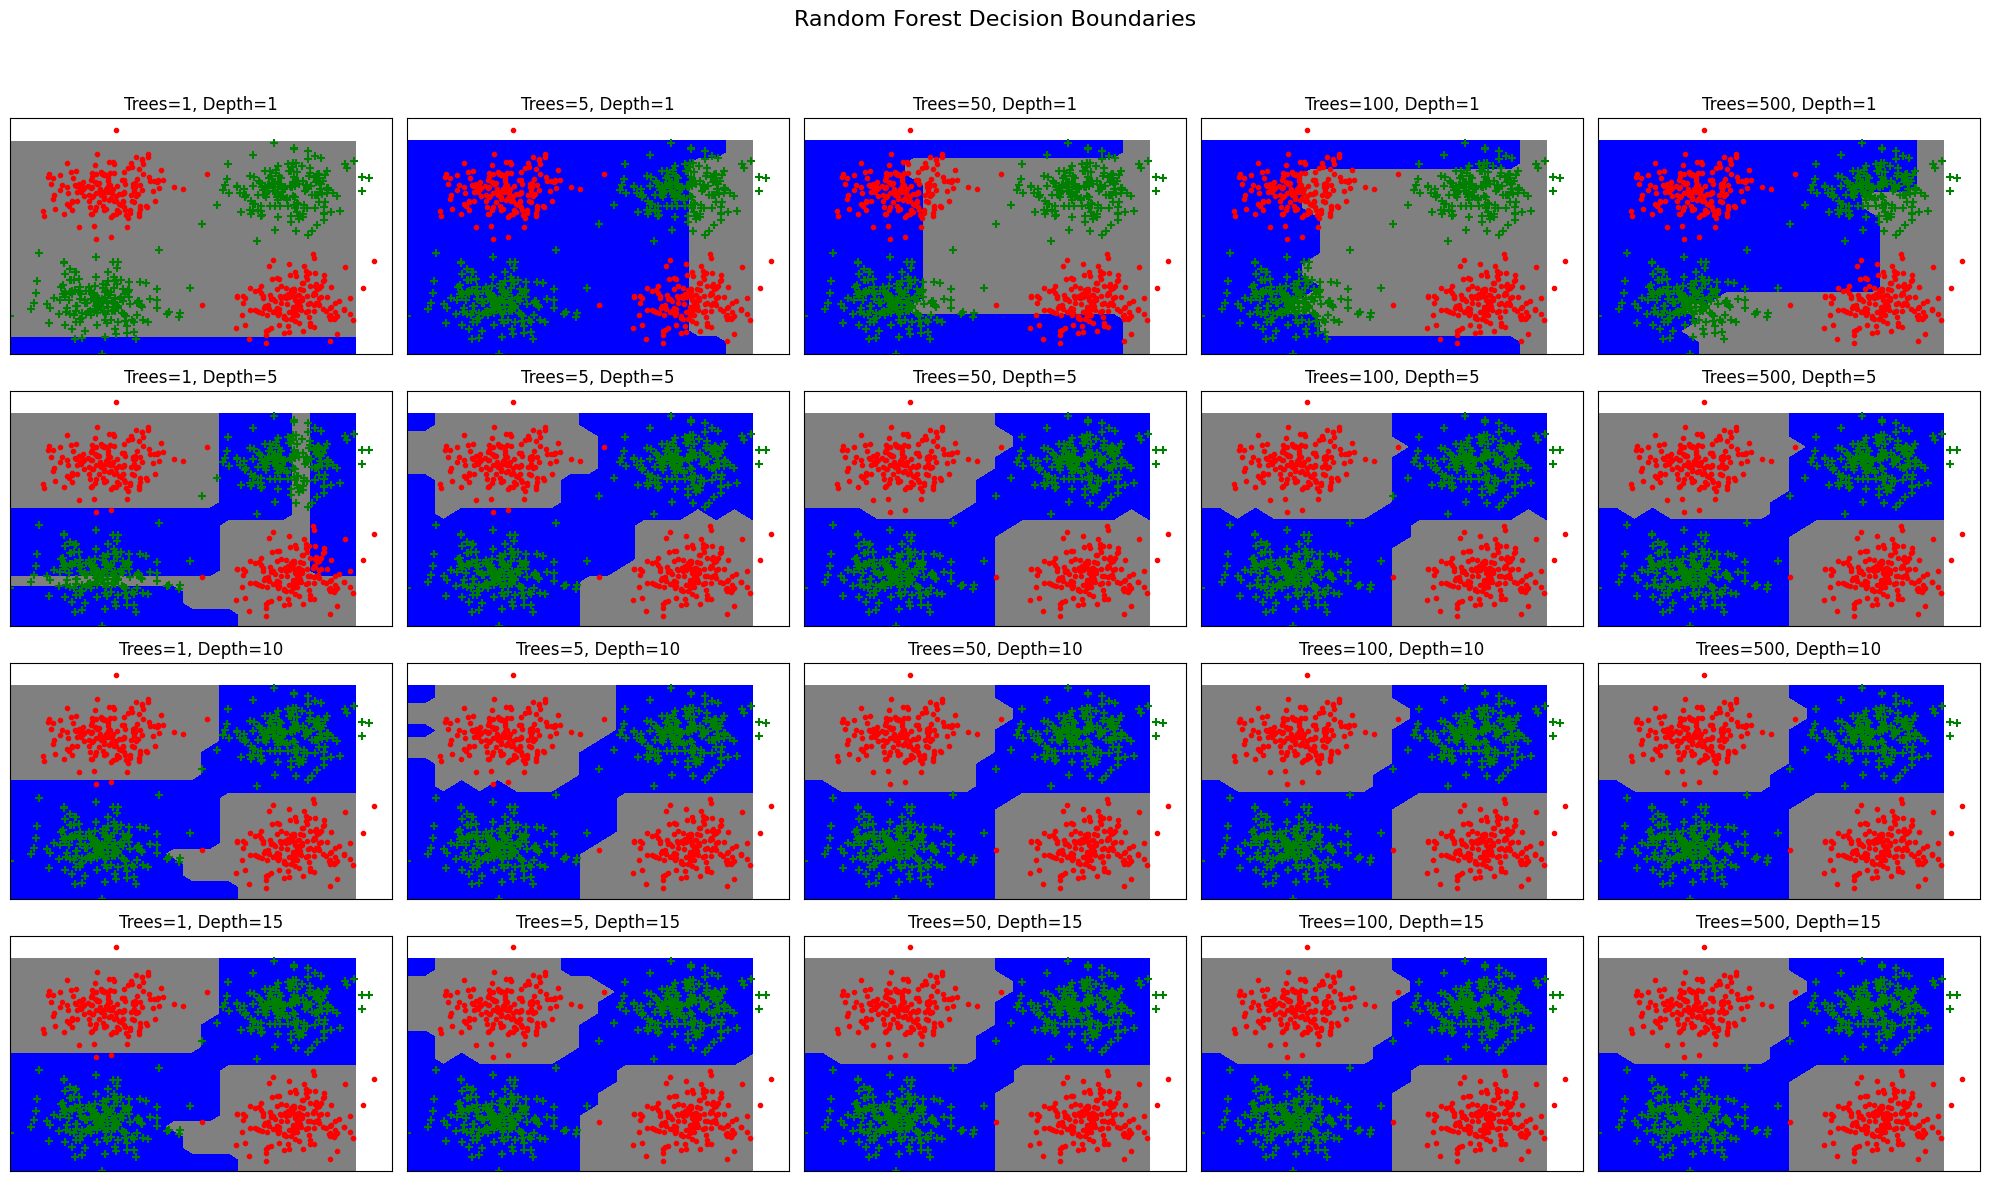

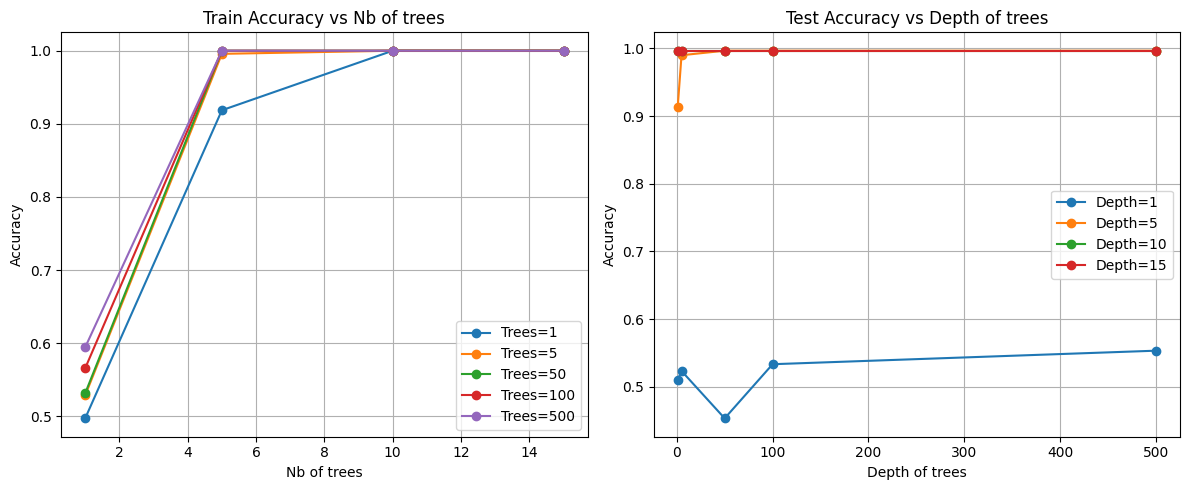

In [20]:
tree_depth = [1,5,10,15]
trees = [1,5,50,100,500]
train_accuracies = []
test_accuracies = []
fig, axes = plt.subplots(len(tree_depth), len(trees), figsize=(20, 12))
fig.suptitle("Random Forest Decision Boundaries", fontsize=16)
for i,depth in enumerate(tree_depth):
    for j,tree in enumerate(trees):
        model = RandomForestClassifier(n_estimators=tree, max_depth=depth, random_state=42)
        model.fit(trainx, trainy.flatten())
        y_train_pred = model.predict(trainx)
        y_test_pred = model.predict(testx)
        train_accuracy = accuracy_score(trainy, y_train_pred)
        test_accuracy = accuracy_score(testy, y_test_pred)
        train_accuracies.append(train_accuracy)
        test_accuracies.append(test_accuracy)
        ax= axes[i, j]
        plt.sca(axes[i, j])

        plot_frontiere(trainx,lambda x: model.predict(x), step=20)
        plot_data(trainx, trainy)
        ax.set_title(f"Trees={tree}, Depth={depth}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

train_accuracies = np.array(train_accuracies).reshape(len(tree_depth), len(trees))
test_accuracies = np.array(test_accuracies).reshape(len(tree_depth), len(trees))
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
for j, tree in enumerate(trees):
    plt.plot(tree_depth, train_accuracies[:, j], marker='o', label=f"Trees={tree}")
plt.title("Train Accuracy vs Nb of trees")
plt.xlabel("Nb of trees")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for i, depth in enumerate(tree_depth):
    plt.plot(trees, test_accuracies[i, :], marker='o', label=f"Depth={depth}")
plt.title("Test Accuracy vs Depth of trees")
plt.xlabel("Depth of trees")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Results

Depth of decision tree - The maximum number of levels in each decision tree.
Nb of trees  - The number of decision trees in the random forest.

Based on the decision boundaries we can observe how the performance changes according to different parameter values. We can see that for nb of trees = 1 the model is really bad and cannot seperate the classes correctly. With more nb of trees and more depth there is better performance. 
This is further confirmed by quantitive data from the graph. With number of trees accuracy increase rapidly. Any nb of tress above 1 already gives good performance. Same in the depth of tress, where 1 give the worst accuracy, close to 0.5 which is guessing level. 
It can be conlcuded that more trees and more depth is always better than less.

## Boosting

In [21]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


In [78]:
class AdaBoost:
    def __init__(self, n_estimators=100): 
        #n_estimators - weak clasifiers
        self.n_estimators = n_estimators
        self.alphas = []
        self.models = []
        self.errors = []
        self.Z = []

    def fit(self, x, y):
        n_samples, n_features = x.shape
        w = np.ones(n_samples) / n_samples

        for _ in range(self.n_estimators):
            model = DecisionTreeClassifier(max_depth=2)
            model.fit(x, y, sample_weight=w)
            y_pred = model.predict(x)

            #calculate error
            
            err = np.sum(w * (y_pred!= y))
            err = np.clip(err, 1e-10, 1 - 1e-10)
            self.errors.append(err)
            alpha = 0.5 * np.log((1 - err) / err)
            self.alphas.append(alpha)
            self.models.append(model)
            w = w * np.exp(-alpha * y * y_pred)
            z = np.sum(w)
            self.Z.append(z)
            w = w / z

            
    
    def predict(self, x):
        preds = np.zeros(x.shape[0])
        for model, alpha in zip(self.models, self.alphas):
            preds += alpha * model.predict(x)
        return np.sign(preds).astype(int)
        
    def score(self, x, y):
        y_pred = self.predict(x)
        return accuracy_score(y, y_pred)



In [79]:
#data generation
data_x,data_y = gen_arti(nbex=1000,data_type=1)
X_train, X_test, y_train, y_test = train_test_split(data_x, data_y.ravel(), test_size=0.3, random_state=42)

adaboost = AdaBoost(n_estimators=100)
adaboost.fit(X_train, y_train)

predictions = adaboost.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


**Experiments**

check for n_estimators

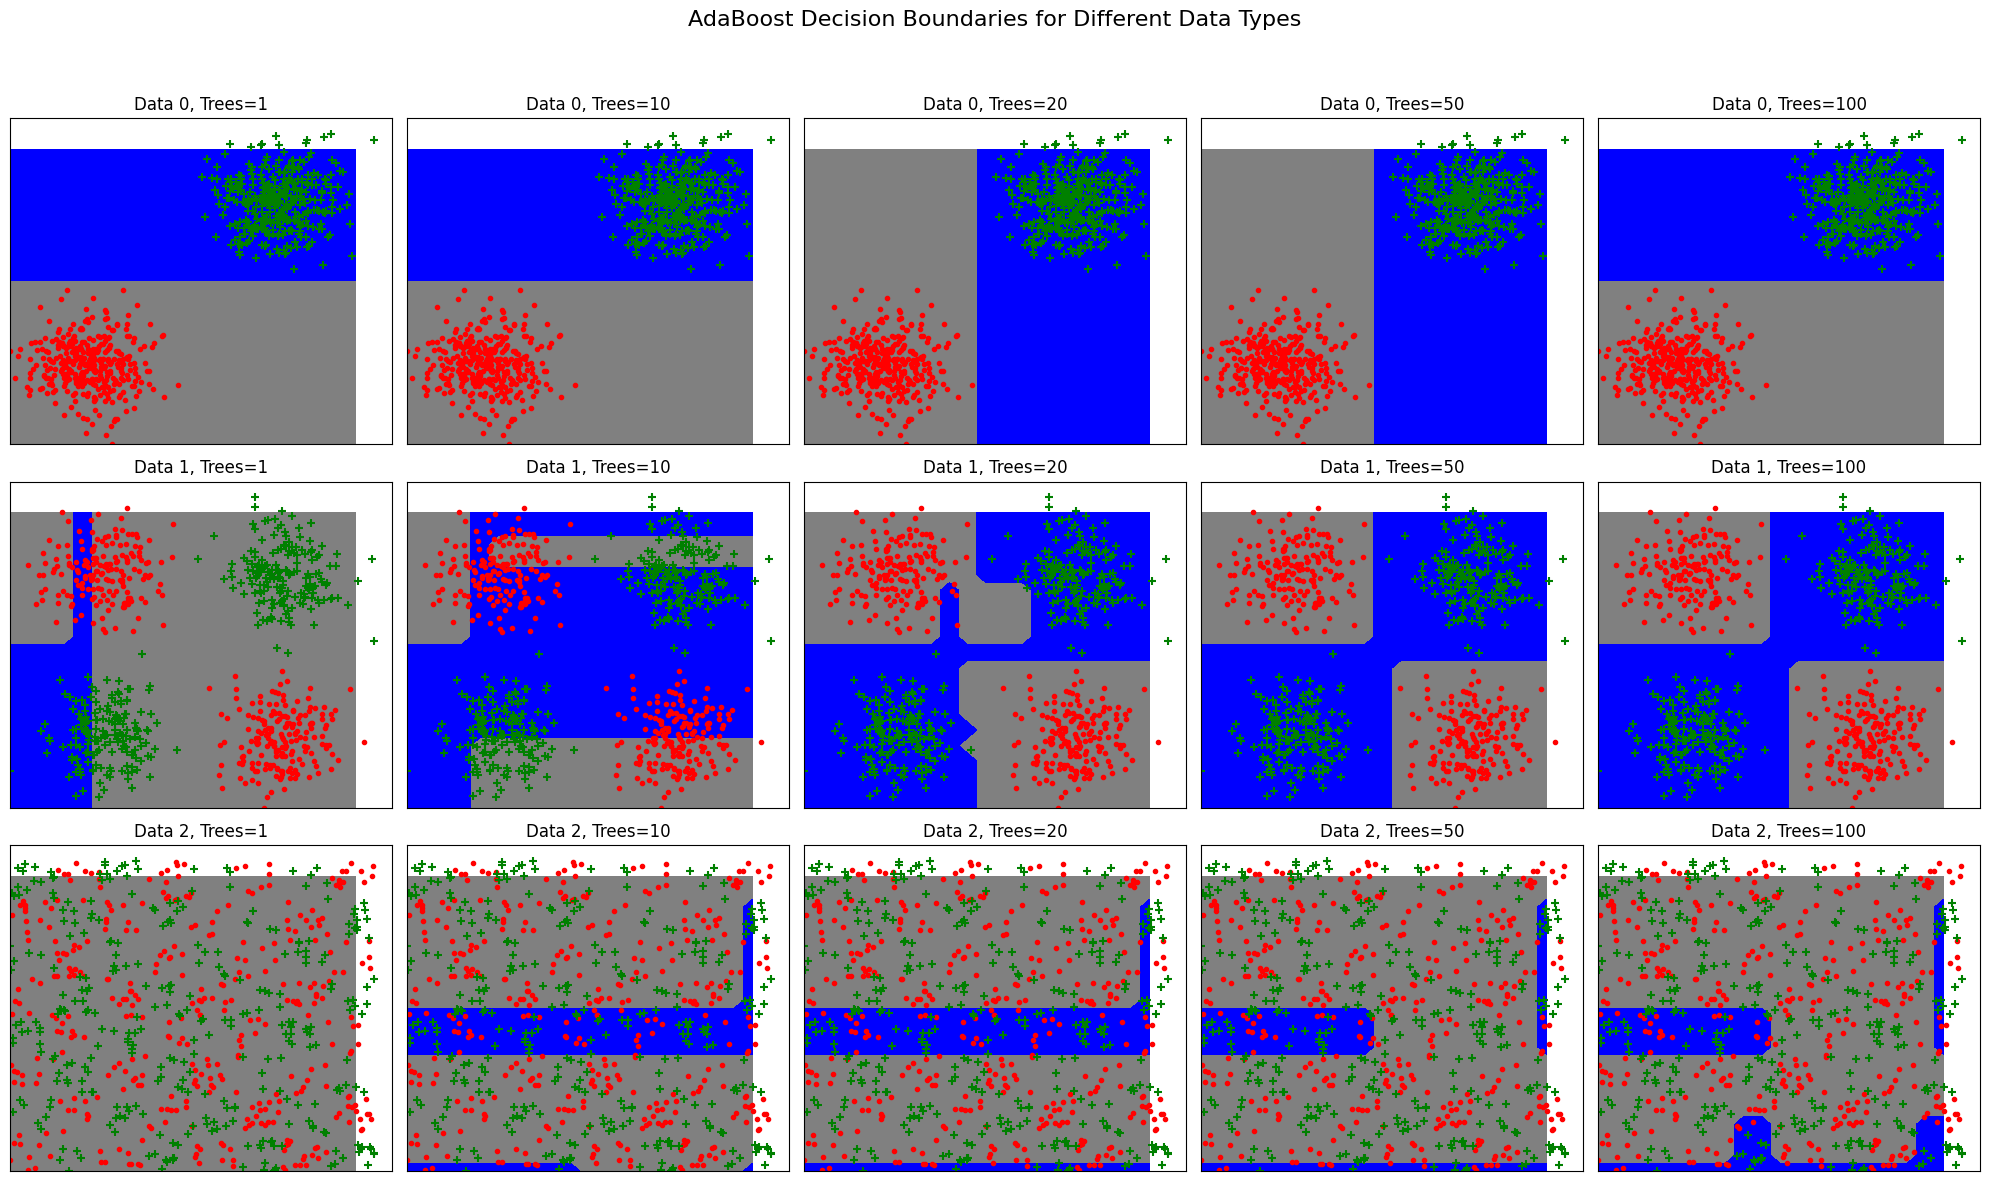

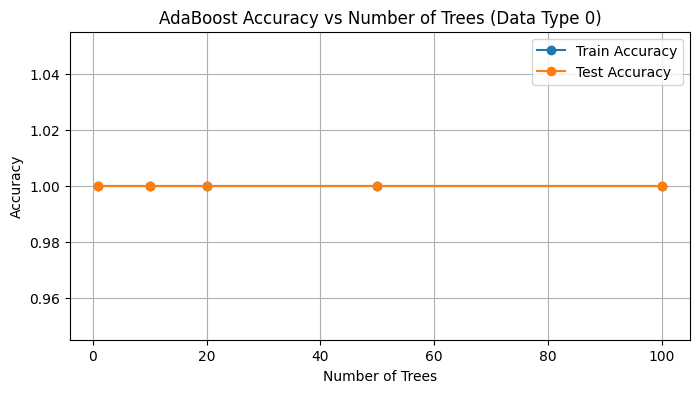

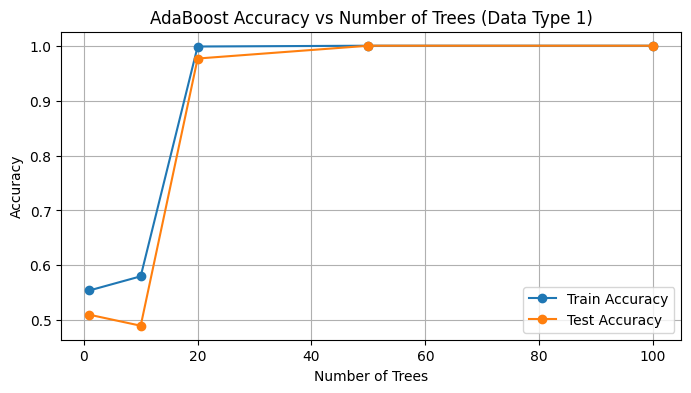

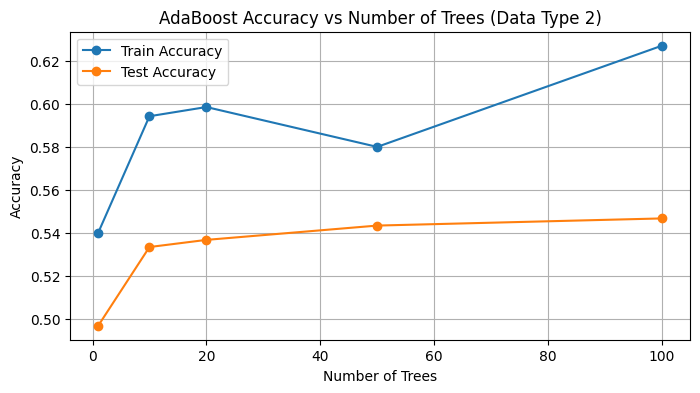

In [80]:
classifier_nb = [1, 10, 20, 50,100]
train_accuracies = []
test_accuracies = []
data_types = [0, 1, 2]

fig, axes = plt.subplots(len(data_types), len(classifier_nb), figsize=(20, 12))
fig.suptitle("AdaBoost Decision Boundaries for Different Data Types", fontsize=16)

all_train_accuracies = []
all_test_accuracies = []
for dtype_idx, dtype in enumerate(data_types):
    data_x, data_y = gen_arti(nbex=1000, data_type=dtype)
    trainx, testx, trainy, testy = train_test_split(data_x, data_y.ravel(), test_size=0.3, random_state=42)

    train_accuracies = []
    test_accuracies = []

    for i, nb in enumerate(classifier_nb):
        adaboost = AdaBoost(n_estimators=nb)
        adaboost.fit(trainx, trainy)
        y_train_pred = adaboost.predict(trainx)
        y_test_pred = adaboost.predict(testx)

        train_accuracy = accuracy_score(trainy, y_train_pred)
        test_accuracy = accuracy_score(testy, y_test_pred)
        train_accuracies.append(train_accuracy)
        test_accuracies.append(test_accuracy)

        ax = axes[dtype_idx, i]
        plt.sca(ax)
        plot_frontiere(trainx, lambda x: adaboost.predict(x), step=20)
        plot_data(trainx, trainy)
        ax.set_title(f"Data {dtype}, Trees={nb}")
        ax.set_xticks([])
        ax.set_yticks([])
    all_train_accuracies.append(train_accuracies)
    all_test_accuracies.append(test_accuracies)


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

for dtype_idx, dtype in enumerate(data_types):
    plt.figure(figsize=(8, 4))
    plt.plot(classifier_nb, all_train_accuracies[dtype_idx], label='Train Accuracy', marker='o')
    plt.plot(classifier_nb, all_test_accuracies[dtype_idx], label='Test Accuracy', marker='o')
    plt.title(f"AdaBoost Accuracy vs Number of Trees (Data Type {dtype})")
    plt.xlabel("Number of Trees")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    

## Results 

We can observe that with linear data the model accuracy is perfect with 100%. No matter how many trees we have we achieve perfect performance. This is because the data is linearly separable. 
For data type 1 we can see that train accuracy is perfect but test accuracy is slightly smaller. Test accuracy converges so it does not further improve. Since the accuracy is still very high 97% we can 'ignore' it and rule out overfitting. 
For the data type 2 (noisy data) we can observe that accuracy increase slower than for the other data types. Train accuracy converges to 100% accuracy. However, test accuracy does not reach 100% and stays below 70%. Here we can observe slight overfitting due to the train and test accuracy being significantly different. 

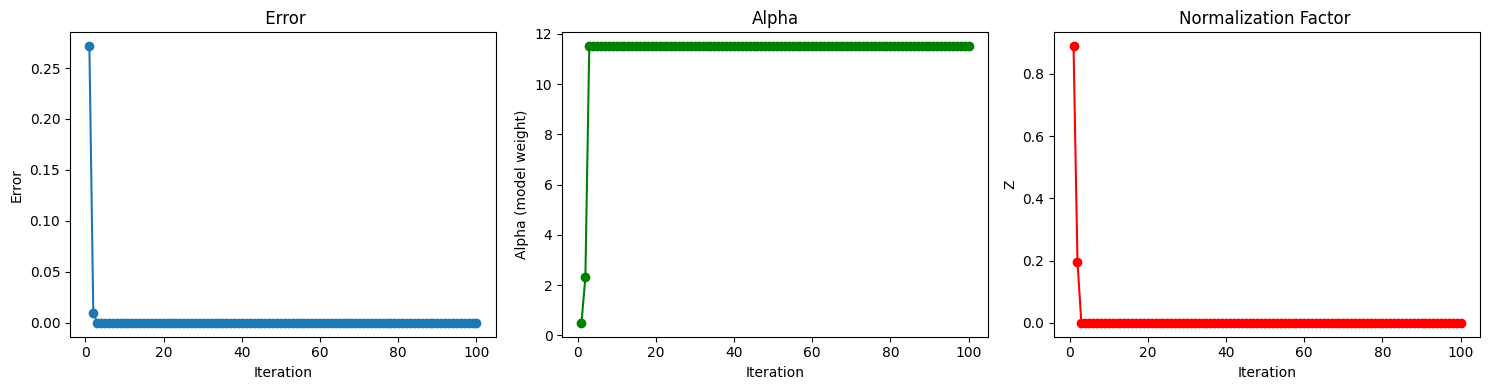

In [81]:
# Train AdaBoost
data_x,data_y = gen_arti(nbex=100,data_type=1)
X_train, X_test, y_train, y_test = train_test_split(data_x, data_y.ravel(), test_size=0.3, random_state=42)

adaboost = AdaBoost(n_estimators=100)
adaboost.fit(X_train, y_train)

# Plot error, alpha, and Z over iterations
iterations = np.arange(1, adaboost.n_estimators + 1)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(iterations, adaboost.errors, marker='o')
plt.title(" Error")
plt.xlabel("Iteration")
plt.ylabel("Error")

plt.subplot(1, 3, 2)
plt.plot(iterations, adaboost.alphas, marker='o', color='green')
plt.title("Alpha")
plt.xlabel("Iteration")
plt.ylabel("Alpha (model weight)")

plt.subplot(1, 3, 3)
plt.plot(iterations, adaboost.Z, marker='o', color='red')
plt.title("Normalization Factor ")
plt.xlabel("Iteration")
plt.ylabel("Z")

plt.tight_layout()
plt.show()


## Results 

error - the weighted error of the weak classifier at each iteration
alpha - the weight assigned to the weak classifier based on its performance
Z - the normalization factor that ensures that the weights of the training samples sum up to 1 after each iteration

We can observe that with data type 1 the accuracy increases rapidly. This means the error of weak classifier becomes 0 quickly, Alpha becomes high, so the weight of the classifier is high early in time, and the normalization factor Z beomes close to 0 because we do not have any error anymore. 

If we change data type to 2 the behavior is more noisy, flactuating more. Error still goes to 0, however it does not fully converge, alpha increases with interation but again no convergence, same behavior for Z factor. This is in line with the accuracy of the model for data type 2, which never converges to 100% but stays around 70%. 

We can observe that error, alpha, Z factor represent the behavior of the model, updating each with every iteration. 